In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import datetime

warnings.filterwarnings('ignore')
%matplotlib inline

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries imported successfully!')

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!


In [11]:
# Load the dataset
# TODO: Replace with your actual file pat
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\South_India_EDA_Practice_Dataset_Fixed.csv") 



In [14]:
print("="*60)
print("DATASET LOADED SUCCESSFULLY!")
print("="*60)
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

DATASET LOADED SUCCESSFULLY!

📊 Dataset Shape: 91300 rows × 16 columns


In [15]:
# Display column names and data types
print("\n" + "="*60)
print("📋 COLUMN NAMES AND DATA TYPES:")
print("="*60)
print(df.dtypes)
print("\n" + "="*60)
print("✅ All columns loaded successfully!")
print("="*60)


📋 COLUMN NAMES AND DATA TYPES:
Date                       str
Year                     int64
Month                    int64
Season                     str
State                      str
District                   str
Station_ID                 str
Rainfall_mm            float64
Temperature_C          float64
Humidity_pct           float64
Wind_Speed_kmh         float64
Pressure_hPa           float64
Cloud_Cover_pct          int64
Reservoir_Level_pct      int64
Flood_Risk                 str
Crop_Type                  str
dtype: object

✅ All columns loaded successfully!



🔍 MISSING VALUES CHECK:
Date                      0
Year                      0
Month                     0
Season                    0
State                     0
District                  0
Station_ID                0
Rainfall_mm               0
Temperature_C             0
Humidity_pct           2764
Wind_Speed_kmh            0
Pressure_hPa              0
Cloud_Cover_pct           0
Reservoir_Level_pct       0
Flood_Risk                0
Crop_Type                 0
dtype: int64

⚠️ Total missing values: 2764


<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

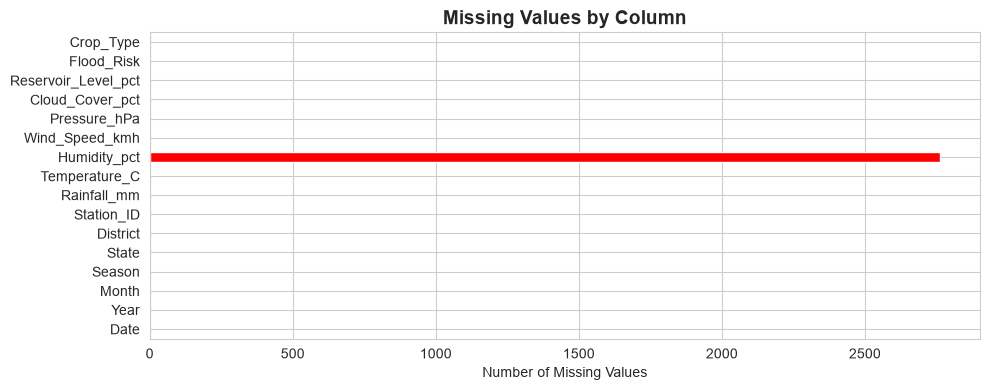

In [19]:
 #Check for missing values
print("\n" + "="*60)
print("🔍 MISSING VALUES CHECK:")
print("="*60)
missing = df.isnull().sum()
print(missing)
print(f"\n⚠️ Total missing values: {df.isnull().sum().sum()}")

# Visualize missing values
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='red')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Missing Values')
    plt.tight_layout()
    plt.show()

In [20]:
# Display first few rows
print("\n" + "="*60)
print("📊 FIRST 5 ROWS OF DATA:")
print("="*60)
df.head()


📊 FIRST 5 ROWS OF DATA:


,Date,Year,Month,Season,State,District,Station_ID,Rainfall_mm,Temperature_C,Humidity_pct,Wind_Speed_kmh,Pressure_hPa,Cloud_Cover_pct,Reservoir_Level_pct,Flood_Risk,Crop_Type
0,2021-01-01,2021,1,Winter,Kerala,D1,ST001,6.4,19.3,59.0,11.9,1006.9,43,51,Low,Coconut
1,2021-01-01,2021,1,Winter,Tamil Nadu,D2,ST002,5.0,21.9,67.0,4.0,998.6,44,29,Low,Banana
2,2021-01-01,2021,1,Winter,Karnataka,D3,ST003,16.8,21.3,85.0,12.5,1002.3,46,51,Low,Rice
3,2021-01-01,2021,1,Winter,Andhra Pradesh,D4,ST004,4.5,23.1,36.0,2.6,1002.2,43,43,Low,Coffee
4,2021-01-01,2021,1,Winter,Telangana,D5,ST005,1.1,24.9,47.0,12.2,1011.3,31,28,Low,Cotton


In [21]:
# Display first few rows
print("\n" + "="*60)
print("📊 FIRST 5 ROWS OF DATA:")
print("="*60)
df.head()


📊 FIRST 5 ROWS OF DATA:


,Date,Year,Month,Season,State,District,Station_ID,Rainfall_mm,Temperature_C,Humidity_pct,Wind_Speed_kmh,Pressure_hPa,Cloud_Cover_pct,Reservoir_Level_pct,Flood_Risk,Crop_Type
0,2021-01-01,2021,1,Winter,Kerala,D1,ST001,6.4,19.3,59.0,11.9,1006.9,43,51,Low,Coconut
1,2021-01-01,2021,1,Winter,Tamil Nadu,D2,ST002,5.0,21.9,67.0,4.0,998.6,44,29,Low,Banana
2,2021-01-01,2021,1,Winter,Karnataka,D3,ST003,16.8,21.3,85.0,12.5,1002.3,46,51,Low,Rice
3,2021-01-01,2021,1,Winter,Andhra Pradesh,D4,ST004,4.5,23.1,36.0,2.6,1002.2,43,43,Low,Coffee
4,2021-01-01,2021,1,Winter,Telangana,D5,ST005,1.1,24.9,47.0,12.2,1011.3,31,28,Low,Cotton


In [22]:
# Display summary statistics
print("\n" + "="*60)
print("📈 SUMMARY STATISTICS:")
print("="*60)
df.describe()


📈 SUMMARY STATISTICS:


,Year,Month,Rainfall_mm,Temperature_C,Humidity_pct,Wind_Speed_kmh,Pressure_hPa,Cloud_Cover_pct,Reservoir_Level_pct
count,91300.000000,91300.000000,91300.000000,91300.000000,88536.000000,91300.000000,91300.000000,91300.000000,91300.000000
mean,2023.000548,6.523549,23.244195,28.705059,67.411019,12.005963,1010.012112,34.151632,43.340887
std,1.414028,3.448552,26.177635,5.491399,19.048251,3.991647,7.980502,14.745676,13.104093
min,2021.000000,1.000000,0.000000,10.800000,35.000000,0.000000,975.900000,0.000000,10.000000
25%,2022.000000,4.000000,6.100000,25.000000,51.000000,9.300000,1004.600000,23.000000,33.000000
50%,2023.000000,7.000000,12.700000,28.400000,68.000000,12.000000,1010.000000,34.000000,43.000000
75%,2024.000000,10.000000,31.500000,32.400000,84.000000,14.700000,1015.400000,45.000000,53.000000
max,2025.000000,12.000000,280.000000,47.200000,100.000000,28.900000,1048.900000,100.000000,100.000000


In [23]:
# Check for duplicates
print("="*60)
print("🔎 CHECKING FOR DUPLICATES:")
print("="*60)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()
    print(f"✅ New dataset shape: {df.shape}")

# Handle missing values
print("\n" + "="*60)
print("🔧 HANDLING MISSING VALUES:")
print("="*60)
print(f"Missing values before cleaning: {df.isnull().sum().sum()}")

# Fill missing values with appropriate methods
# For numerical columns: fill with mean
# For categorical columns: fill with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].mean(), inplace=True)
            print(f"✅ Filled {col} with mean value")
        else:
            df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)
            print(f"✅ Filled {col} with mode value")

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")
print("\n✅ DATA CLEANING COMPLETE!")

🔎 CHECKING FOR DUPLICATES:
Total duplicate rows: 0

🔧 HANDLING MISSING VALUES:
Missing values before cleaning: 2764
✅ Filled Humidity_pct with mean value

Missing values after cleaning: 2764

✅ DATA CLEANING COMPLETE!


📈 NUMERICAL COLUMNS ANALYSIS:
Numerical columns: ['Year', 'Month', 'Rainfall_mm', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Pressure_hPa', 'Cloud_Cover_pct', 'Reservoir_Level_pct']

Detailed statistics:
               Year         Month   Rainfall_mm  Temperature_C  Humidity_pct  \
count  91300.000000  91300.000000  91300.000000   91300.000000  88536.000000   
mean    2023.000548      6.523549     23.244195      28.705059     67.411019   
std        1.414028      3.448552     26.177635       5.491399     19.048251   
min     2021.000000      1.000000      0.000000      10.800000     35.000000   
25%     2022.000000      4.000000      6.100000      25.000000     51.000000   
50%     2023.000000      7.000000     12.700000      28.400000     68.000000   
75%     2024.000000     10.000000     31.500000      32.400000     84.000000   
max     2025.000000     12.000000    280.000000      47.200000    100.000000   

       Wind_Speed_kmh  Pressure_hPa  Cloud_Cover_pct  Reservoir_Le

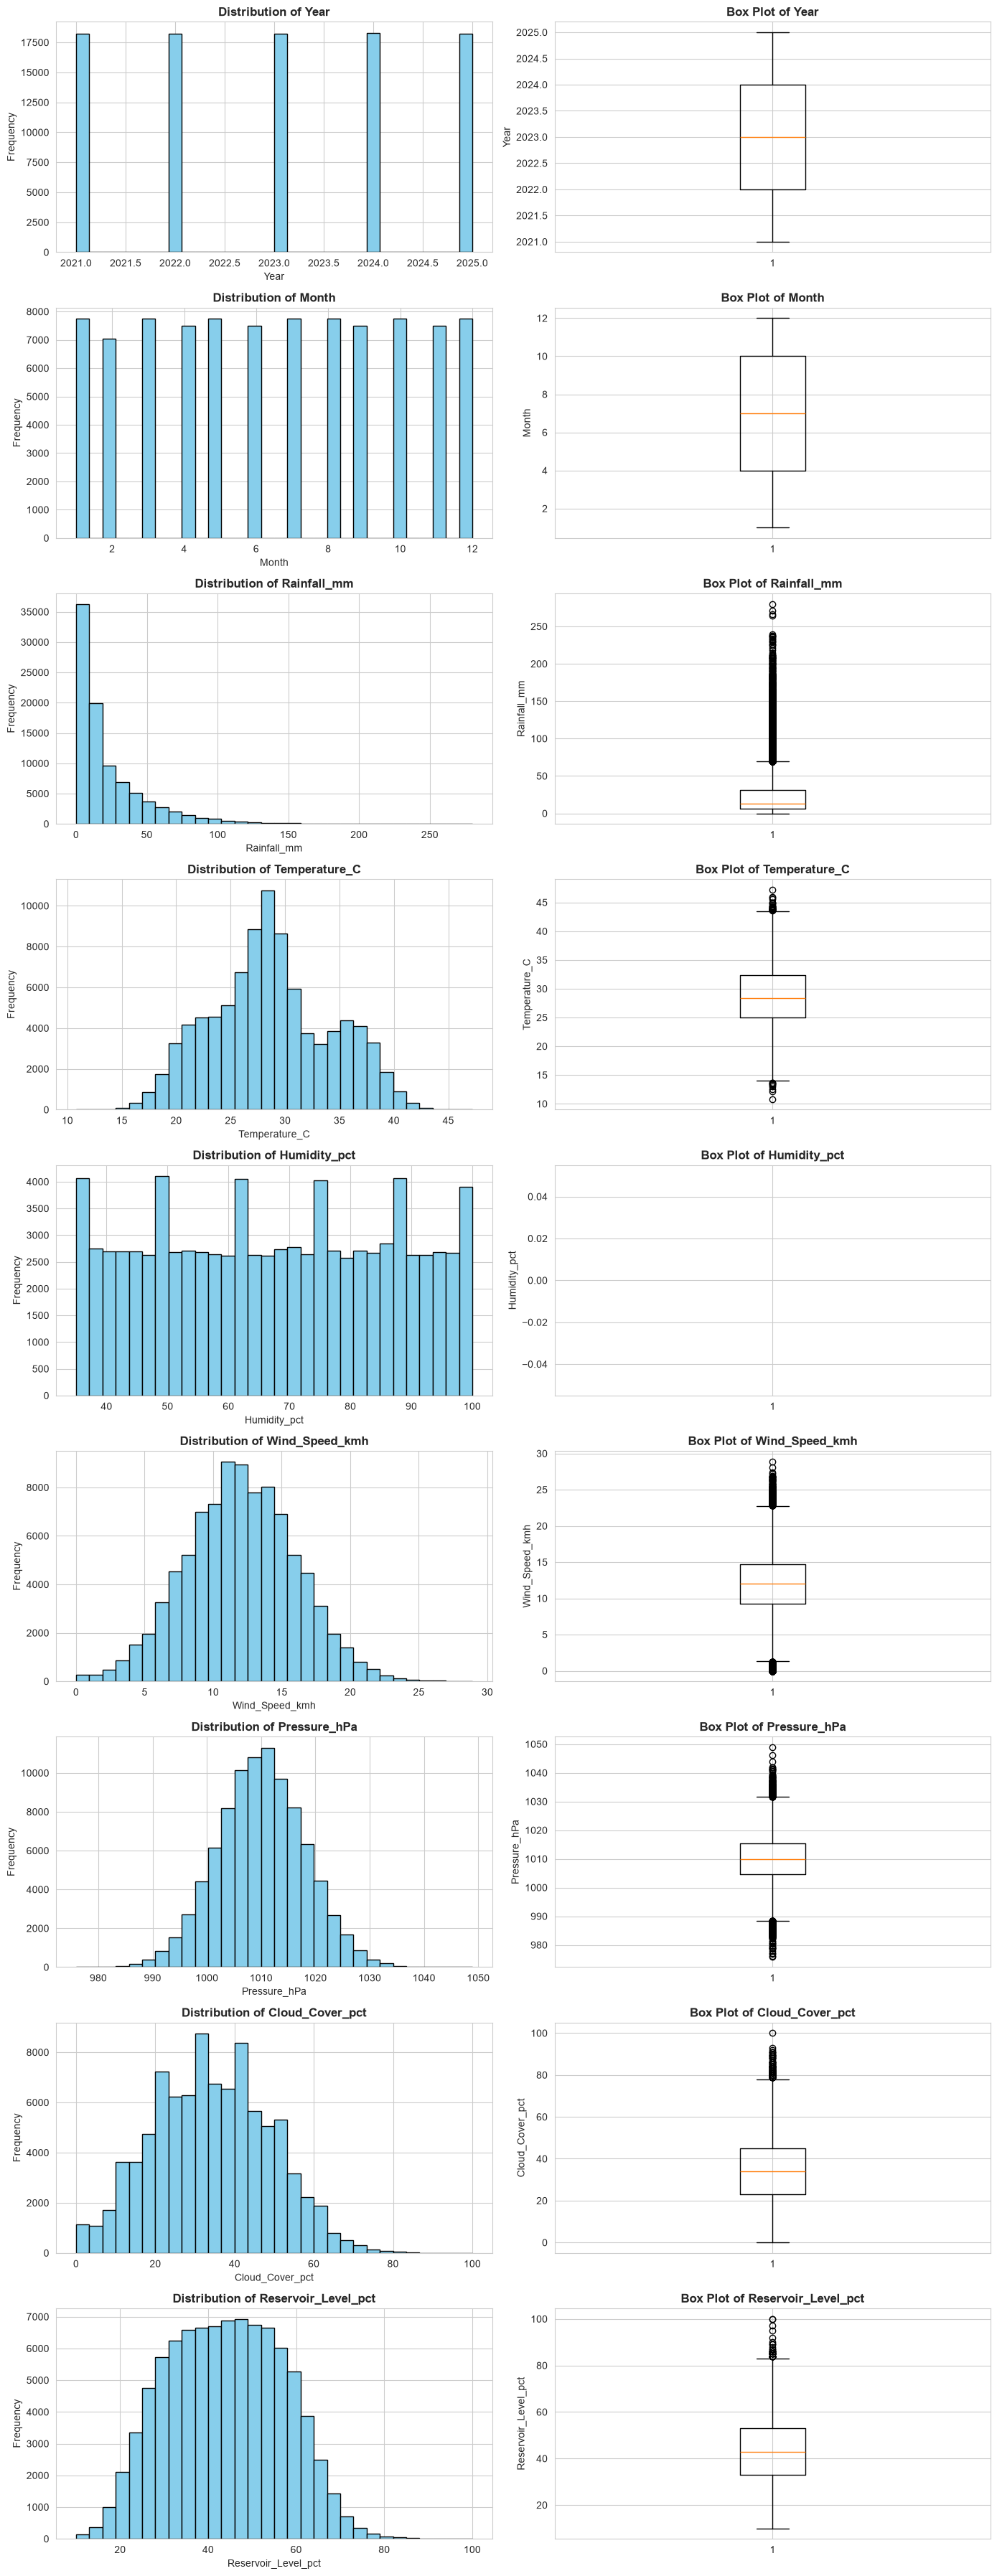


🏷️ CATEGORICAL COLUMNS ANALYSIS:
Categorical columns: ['Date', 'Season', 'State', 'District', 'Station_ID', 'Flood_Risk', 'Crop_Type']

Date - Value Counts:
Date
2021-01-01    50
2021-01-02    50
2021-01-03    50
2021-01-04    50
2021-01-05    50
              ..
2025-12-27    50
2025-12-28    50
2025-12-29    50
2025-12-30    50
2025-12-31    50
Name: count, Length: 1826, dtype: int64

Season - Value Counts:
Season
Monsoon         30500
Summer          23000
Winter          22550
Post-Monsoon    15250
Name: count, dtype: int64

State - Value Counts:
State
Kerala            18260
Tamil Nadu        18260
Karnataka         18260
Andhra Pradesh    18260
Telangana         18260
Name: count, dtype: int64

District - Value Counts:
District
D1    18260
D2    18260
D3    18260
D4    18260
D5    18260
Name: count, dtype: int64

Station_ID - Value Counts:
Station_ID
ST001    1826
ST002    1826
ST003    1826
ST004    1826
ST005    1826
ST006    1826
ST007    1826
ST008    1826
ST009    1826
ST01

In [24]:
# Get numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*60)
print("📈 NUMERICAL COLUMNS ANALYSIS:")
print("="*60)
print(f"Numerical columns: {numerical_cols}")
print(f"\nDetailed statistics:\n{df[numerical_cols].describe()}")

# Visualize numerical distributions
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 4*len(numerical_cols)))
if len(numerical_cols) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numerical_cols):
    # Histogram
    axes[idx, 0].hist(df[col], bins=30, color='skyblue', edgecolor='black')
    axes[idx, 0].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Frequency')
    
    # Box plot
    axes[idx, 1].boxplot(df[col])
    axes[idx, 1].set_title(f'Box Plot of {col}', fontweight='bold')
    axes[idx, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🏷️ CATEGORICAL COLUMNS ANALYSIS:")
print("="*60)
print(f"Categorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col} - Value Counts:")
    print(df[col].value_counts())

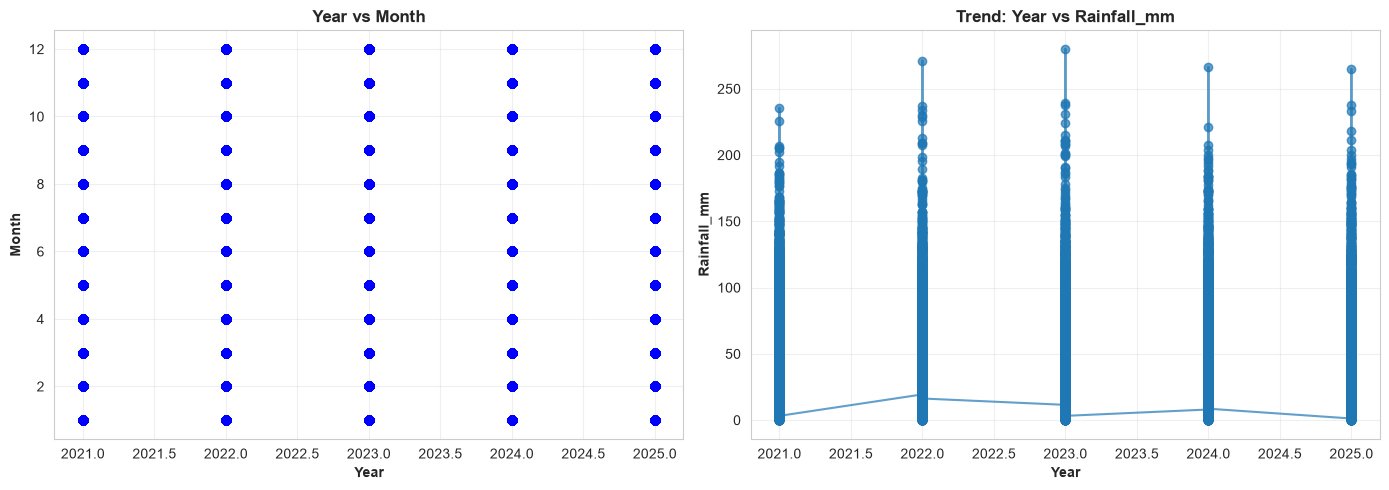


🏷️ CATEGORICAL vs NUMERICAL ANALYSIS:


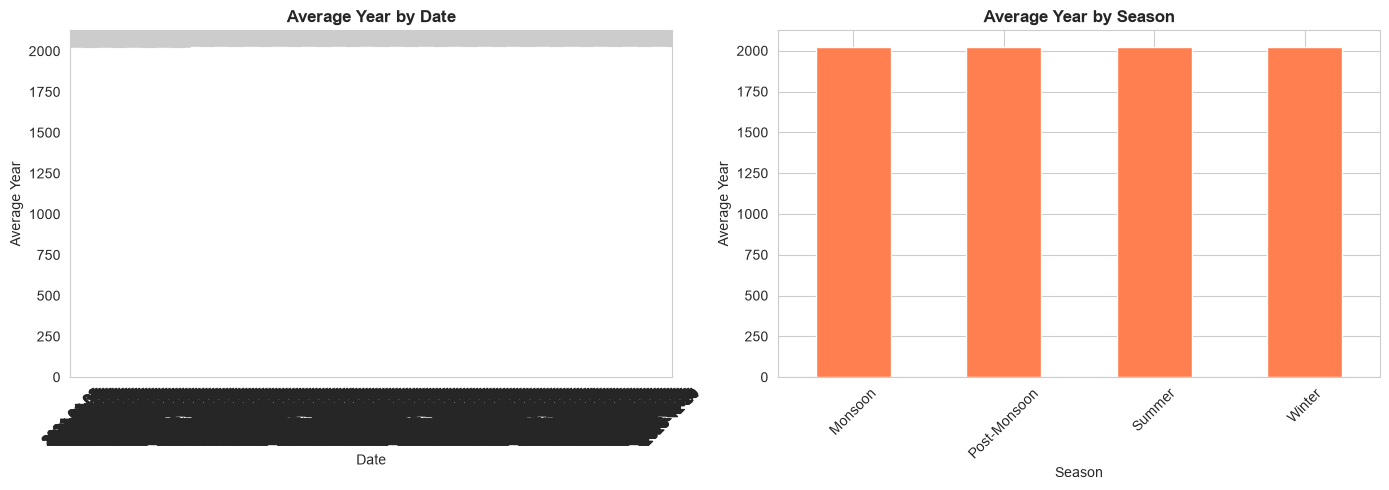

In [25]:
# Select first 2-3 numerical columns for visualization (to avoid too many plots)
if len(numerical_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot: First vs Second column
    axes[0].scatter(df[numerical_cols[0]], df[numerical_cols[1]], alpha=0.5, color='blue')
    axes[0].set_xlabel(numerical_cols[0], fontweight='bold')
    axes[0].set_ylabel(numerical_cols[1], fontweight='bold')
    axes[0].set_title(f'{numerical_cols[0]} vs {numerical_cols[1]}', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Line plot: Trend
    if len(numerical_cols) >= 3:
        axes[1].plot(df[numerical_cols[0]], df[numerical_cols[2]], marker='o', linestyle='-', alpha=0.7)
        axes[1].set_xlabel(numerical_cols[0], fontweight='bold')
        axes[1].set_ylabel(numerical_cols[2], fontweight='bold')
        axes[1].set_title(f'Trend: {numerical_cols[0]} vs {numerical_cols[2]}', fontweight='bold')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Categorical vs Numerical analysis
if len(categorical_cols) > 0 and len(numerical_cols) > 0:
    print("\n" + "="*60)
    print("🏷️ CATEGORICAL vs NUMERICAL ANALYSIS:")
    print("="*60)
    fig, axes = plt.subplots(1, min(2, len(categorical_cols)), figsize=(14, 5))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, cat_col in enumerate(categorical_cols[:2]):
        grouped = df.groupby(cat_col)[numerical_cols[0]].mean()
        grouped.plot(kind='bar', ax=axes[idx], color='coral')
        axes[idx].set_title(f'Average {numerical_cols[0]} by {cat_col}', fontweight='bold')
        axes[idx].set_xlabel(cat_col)
        axes[idx].set_ylabel(f'Average {numerical_cols[0]}')
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

🔗 CORRELATION MATRIX:
                         Year     Month  Rainfall_mm  Temperature_C  \
Year                 1.000000 -0.000508    -0.002342       0.001440   
Month               -0.000508  1.000000     0.254473      -0.172603   
Rainfall_mm         -0.002342  0.254473     1.000000      -0.004921   
Temperature_C        0.001440 -0.172603    -0.004921       1.000000   
Humidity_pct        -0.000153  0.003854    -0.000567      -0.004127   
Wind_Speed_kmh      -0.001750  0.000174     0.000026      -0.000430   
Pressure_hPa        -0.002805  0.001619     0.001846       0.004970   
Cloud_Cover_pct     -0.001650  0.080652     0.317969       0.000334   
Reservoir_Level_pct -0.003555  0.077198     0.281366      -0.005050   

                     Humidity_pct  Wind_Speed_kmh  Pressure_hPa  \
Year                    -0.000153       -0.001750     -0.002805   
Month                    0.003854        0.000174      0.001619   
Rainfall_mm             -0.000567        0.000026      0.001846   

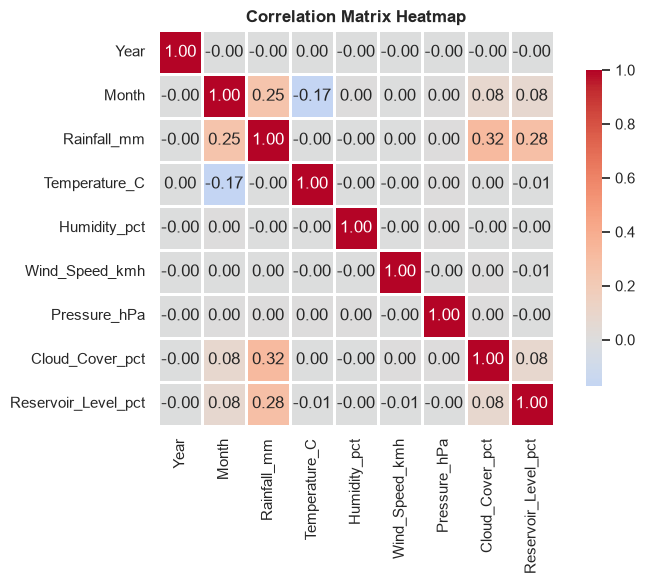


💪 STRONG CORRELATIONS (|correlation| > 0.7):
No strong correlations found.


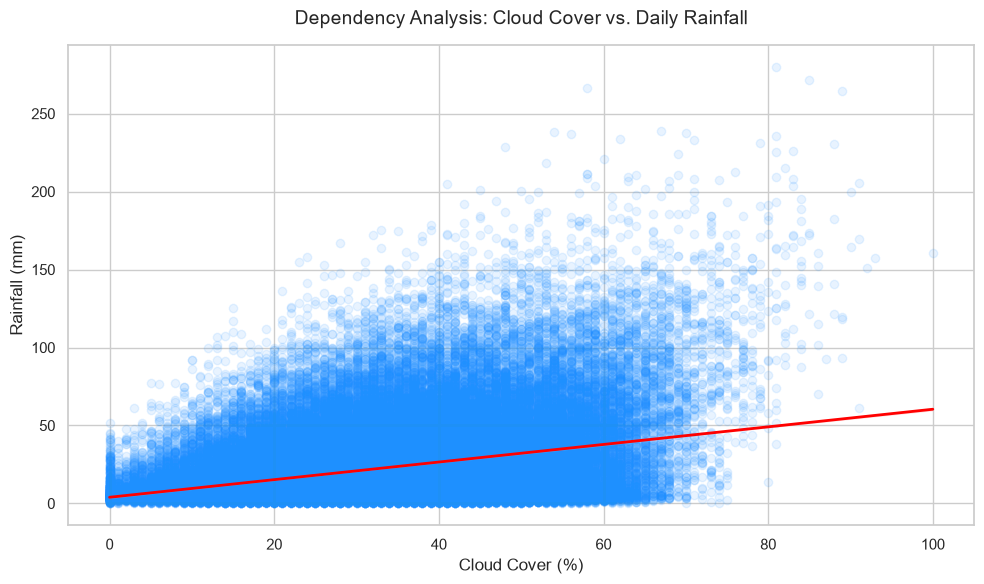

In [30]:
# Calculate correlation matrix
print("="*60)
print("🔗 CORRELATION MATRIX:")
print("="*60)
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Visualize correlation matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations (> 0.7 or < -0.7)
print("\n" + "="*60)
print("💪 STRONG CORRELATIONS (|correlation| > 0.7):")
print("="*60)
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df)
else:
    print("No strong correlations found.")
    plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Regplot draws individual points with transparency and a clear red trend line
sns.regplot(
    data=df, 
    x='Cloud_Cover_pct', 
    y='Rainfall_mm', 
    scatter_kws={'alpha': 0.1, 'color': 'dodgerblue'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Dependency Analysis: Cloud Cover vs. Daily Rainfall', fontsize=14, pad=15)
plt.xlabel('Cloud Cover (%)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)

plt.tight_layout()
plt.show()

⏳ TIME SERIES ANALYSIS:


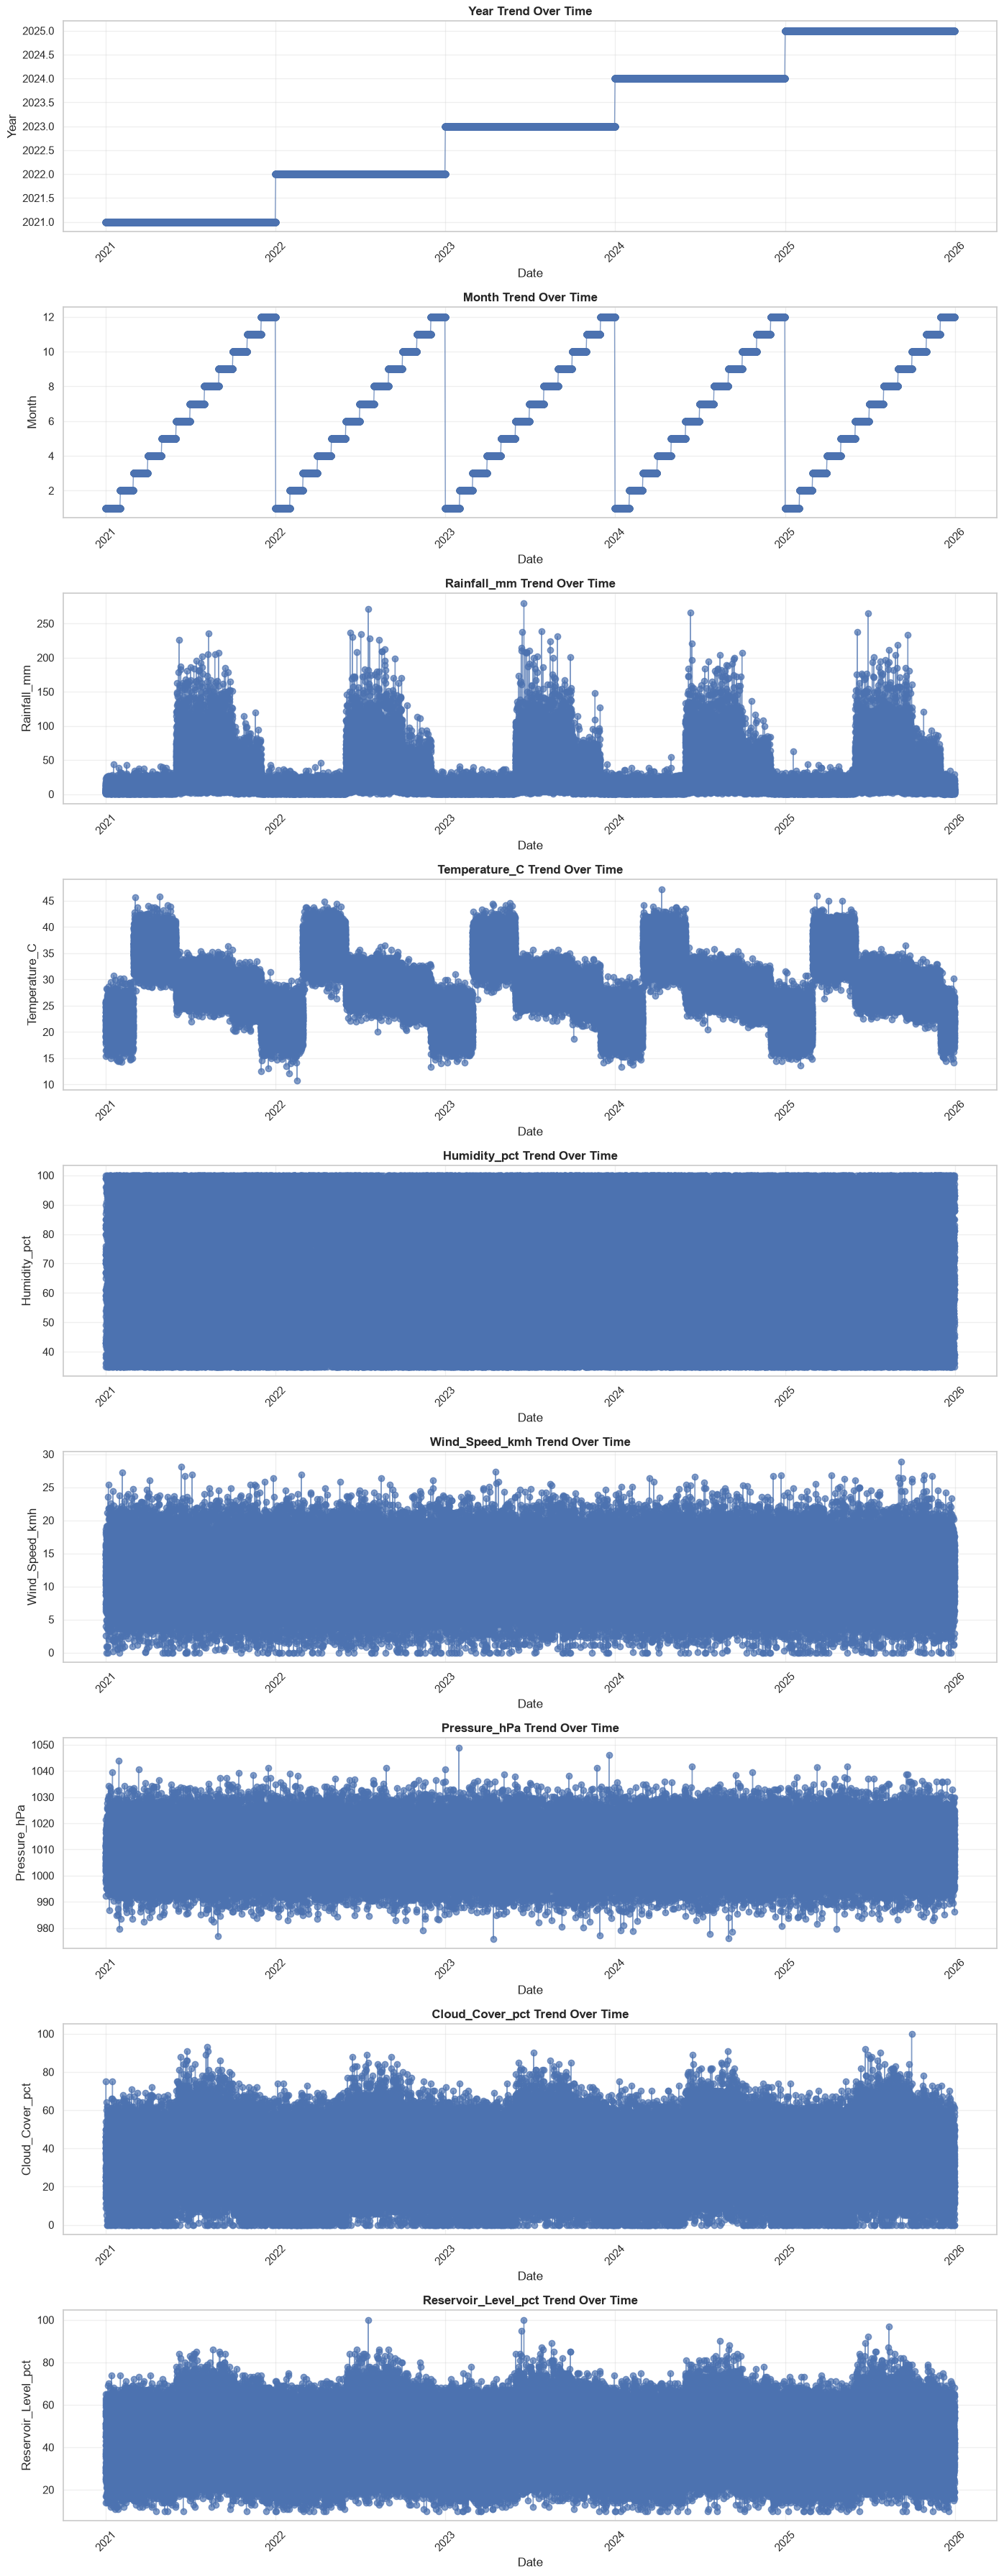


📊 MONTHLY AGGREGATION:
             Year  Month  Rainfall_mm  Temperature_C  Humidity_pct  \
YearMonth                                                            
2021-01    2021.0    1.0     7.591226      21.992645     67.750996   
2021-02    2021.0    2.0     7.755500      21.928143     66.821455   
2021-03    2021.0    3.0     7.883032      36.119742     66.875167   
2021-04    2021.0    4.0     7.770067      36.017867     67.347411   
2021-05    2021.0    5.0     7.859871      35.919548     67.947403   
2021-06    2021.0    6.0    47.759200      28.974867     66.987004   
2021-07    2021.0    7.0    45.755613      29.034968     67.475553   
2021-08    2021.0    8.0    47.077484      28.987548     67.331565   
2021-09    2021.0    9.0    47.617933      28.894000     67.802622   
2021-10    2021.0   10.0    23.536194      27.042000     67.895403   
2021-11    2021.0   11.0    23.160867      26.900333     67.828966   
2021-12    2021.0   12.0     7.673355      22.076839     66.962401

In [31]:
# Check if there's a date column (common names: Date, date, timestamp, Timestamp, etc.)
date_col = None
for col in df.columns:
    if col.lower() in ['date', 'timestamp', 'time', 'datetime']:
        date_col = col
        break

if date_col:
    print("="*60)
    print("⏳ TIME SERIES ANALYSIS:")
    print("="*60)
    
    # Convert to datetime if not already
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # Sort by date
    df = df.sort_values(by=date_col)
    
    # Plot trends for numerical columns over time
    fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(14, 4*len(numerical_cols)))
    if len(numerical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].plot(df[date_col], df[col], marker='o', linestyle='-', alpha=0.7, linewidth=1)
        axes[idx].set_title(f'{col} Trend Over Time', fontweight='bold')
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Monthly aggregation
    print("\n" + "="*60)
    print("📊 MONTHLY AGGREGATION:")
    print("="*60)
    df['YearMonth'] = df[date_col].dt.to_period('M')
    monthly_avg = df.groupby('YearMonth')[numerical_cols].mean()
    print(monthly_avg)
    
else:
    print("⚠️ No date column found. Skipping time series analysis.")
    print("To enable time series analysis, ensure your dataset has a 'date' or 'timestamp' column.")

⏳ TIME SERIES ANALYSIS:


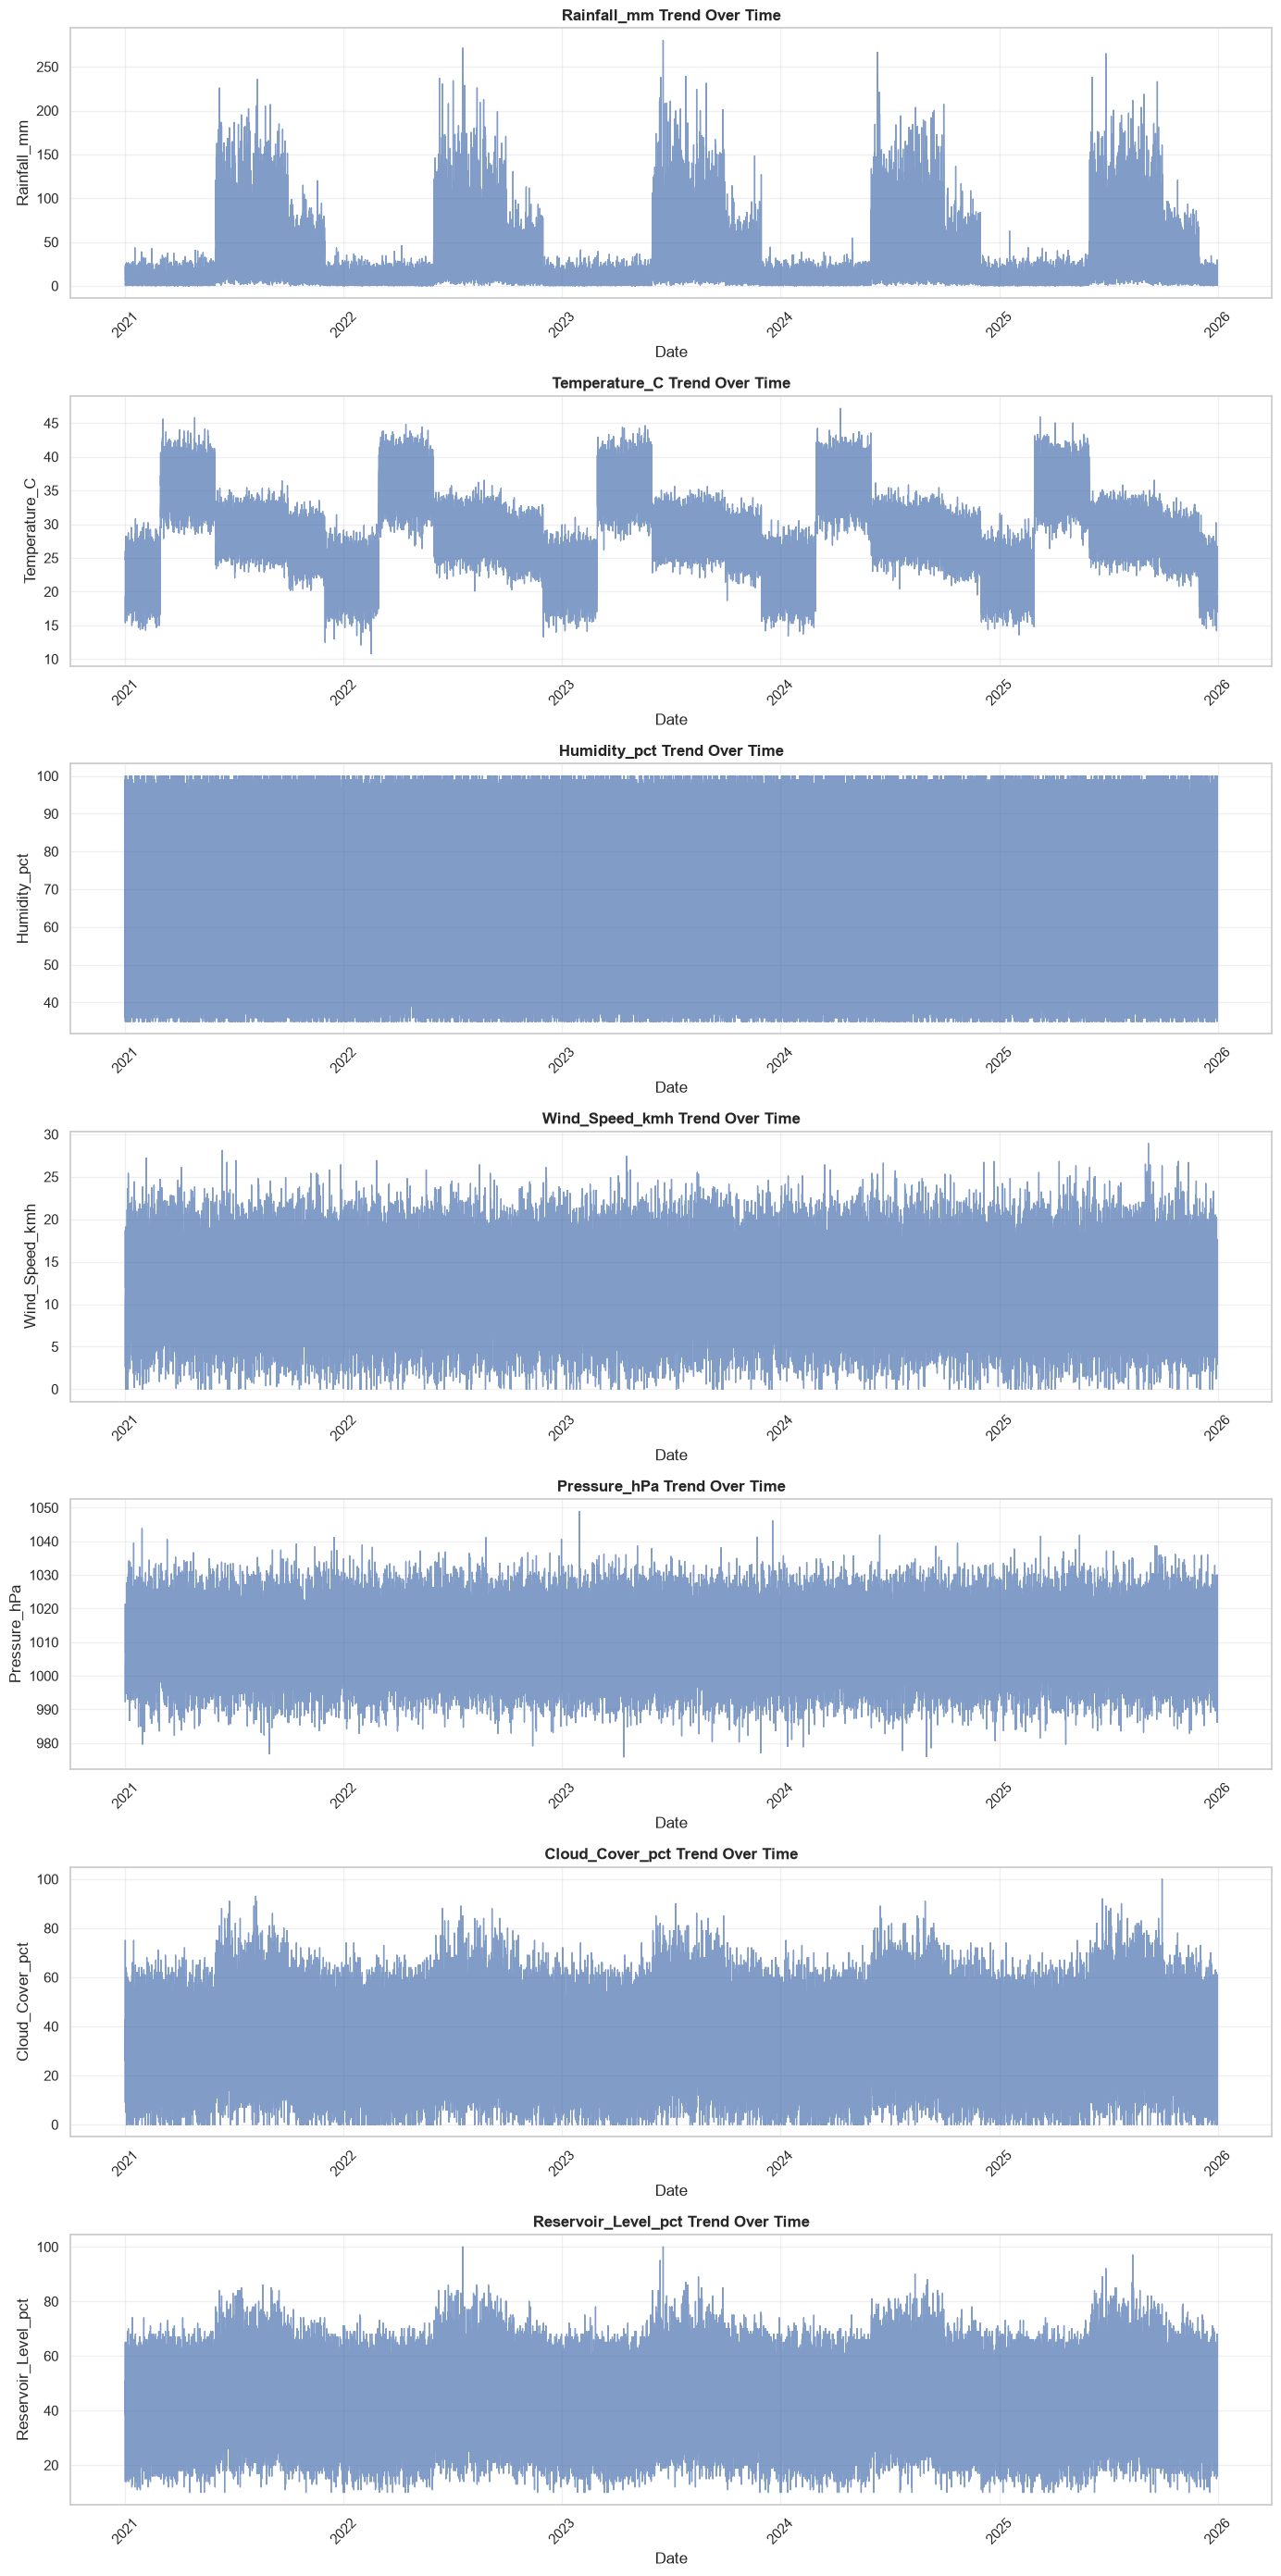


📊 MONTHLY AGGREGATION:
             Year  Month  Rainfall_mm  Temperature_C  Humidity_pct  \
YearMonth                                                            
2021-01    2021.0    1.0     7.591226      21.992645     67.750996   
2021-02    2021.0    2.0     7.755500      21.928143     66.821455   
2021-03    2021.0    3.0     7.883032      36.119742     66.875167   
2021-04    2021.0    4.0     7.770067      36.017867     67.347411   
2021-05    2021.0    5.0     7.859871      35.919548     67.947403   
2021-06    2021.0    6.0    47.759200      28.974867     66.987004   
2021-07    2021.0    7.0    45.755613      29.034968     67.475553   
2021-08    2021.0    8.0    47.077484      28.987548     67.331565   
2021-09    2021.0    9.0    47.617933      28.894000     67.802622   
2021-10    2021.0   10.0    23.536194      27.042000     67.895403   
2021-11    2021.0   11.0    23.160867      26.900333     67.828966   
2021-12    2021.0   12.0     7.673355      22.076839     66.962401

In [32]:
if date_col:
    print("="*60)
    print("⏳ TIME SERIES ANALYSIS:")
    print("="*60)
    
    # Convert to datetime if not already
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # Sort by date
    df = df.sort_values(by=date_col)
    
    # FIX 1: Filter out 'Year' and 'Month' from the plotting list 
    # to avoid rendering redundant, flat/step lines
    plot_cols = [c for c in numerical_cols if c.lower() not in ['year', 'month']]
    
    # Plot trends for actual physical columns over time
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 4 * len(plot_cols)))
    
    # Handle edge case if there's only 1 column to plot
    if len(plot_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(plot_cols):
        # FIX 2: Removed marker='o' to massively cut down memory usage 
        # and prevent Jupyter renderer from crashing on multi-year daily data
        axes[idx].plot(df[date_col], df[col], linestyle='-', alpha=0.7, linewidth=1)
        axes[idx].set_title(f'{col} Trend Over Time', fontweight='bold')
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()  
    
    # Monthly aggregation (keeps the original numerical_cols layout for your table)
    print("\n" + "="*60)
    print("📊 MONTHLY AGGREGATION:")
    print("="*60)
    df['YearMonth'] = df[date_col].dt.to_period('M')
    monthly_avg = df.groupby('YearMonth')[numerical_cols].mean()
    print(monthly_avg)

⏳ TIME SERIES ANALYSIS:


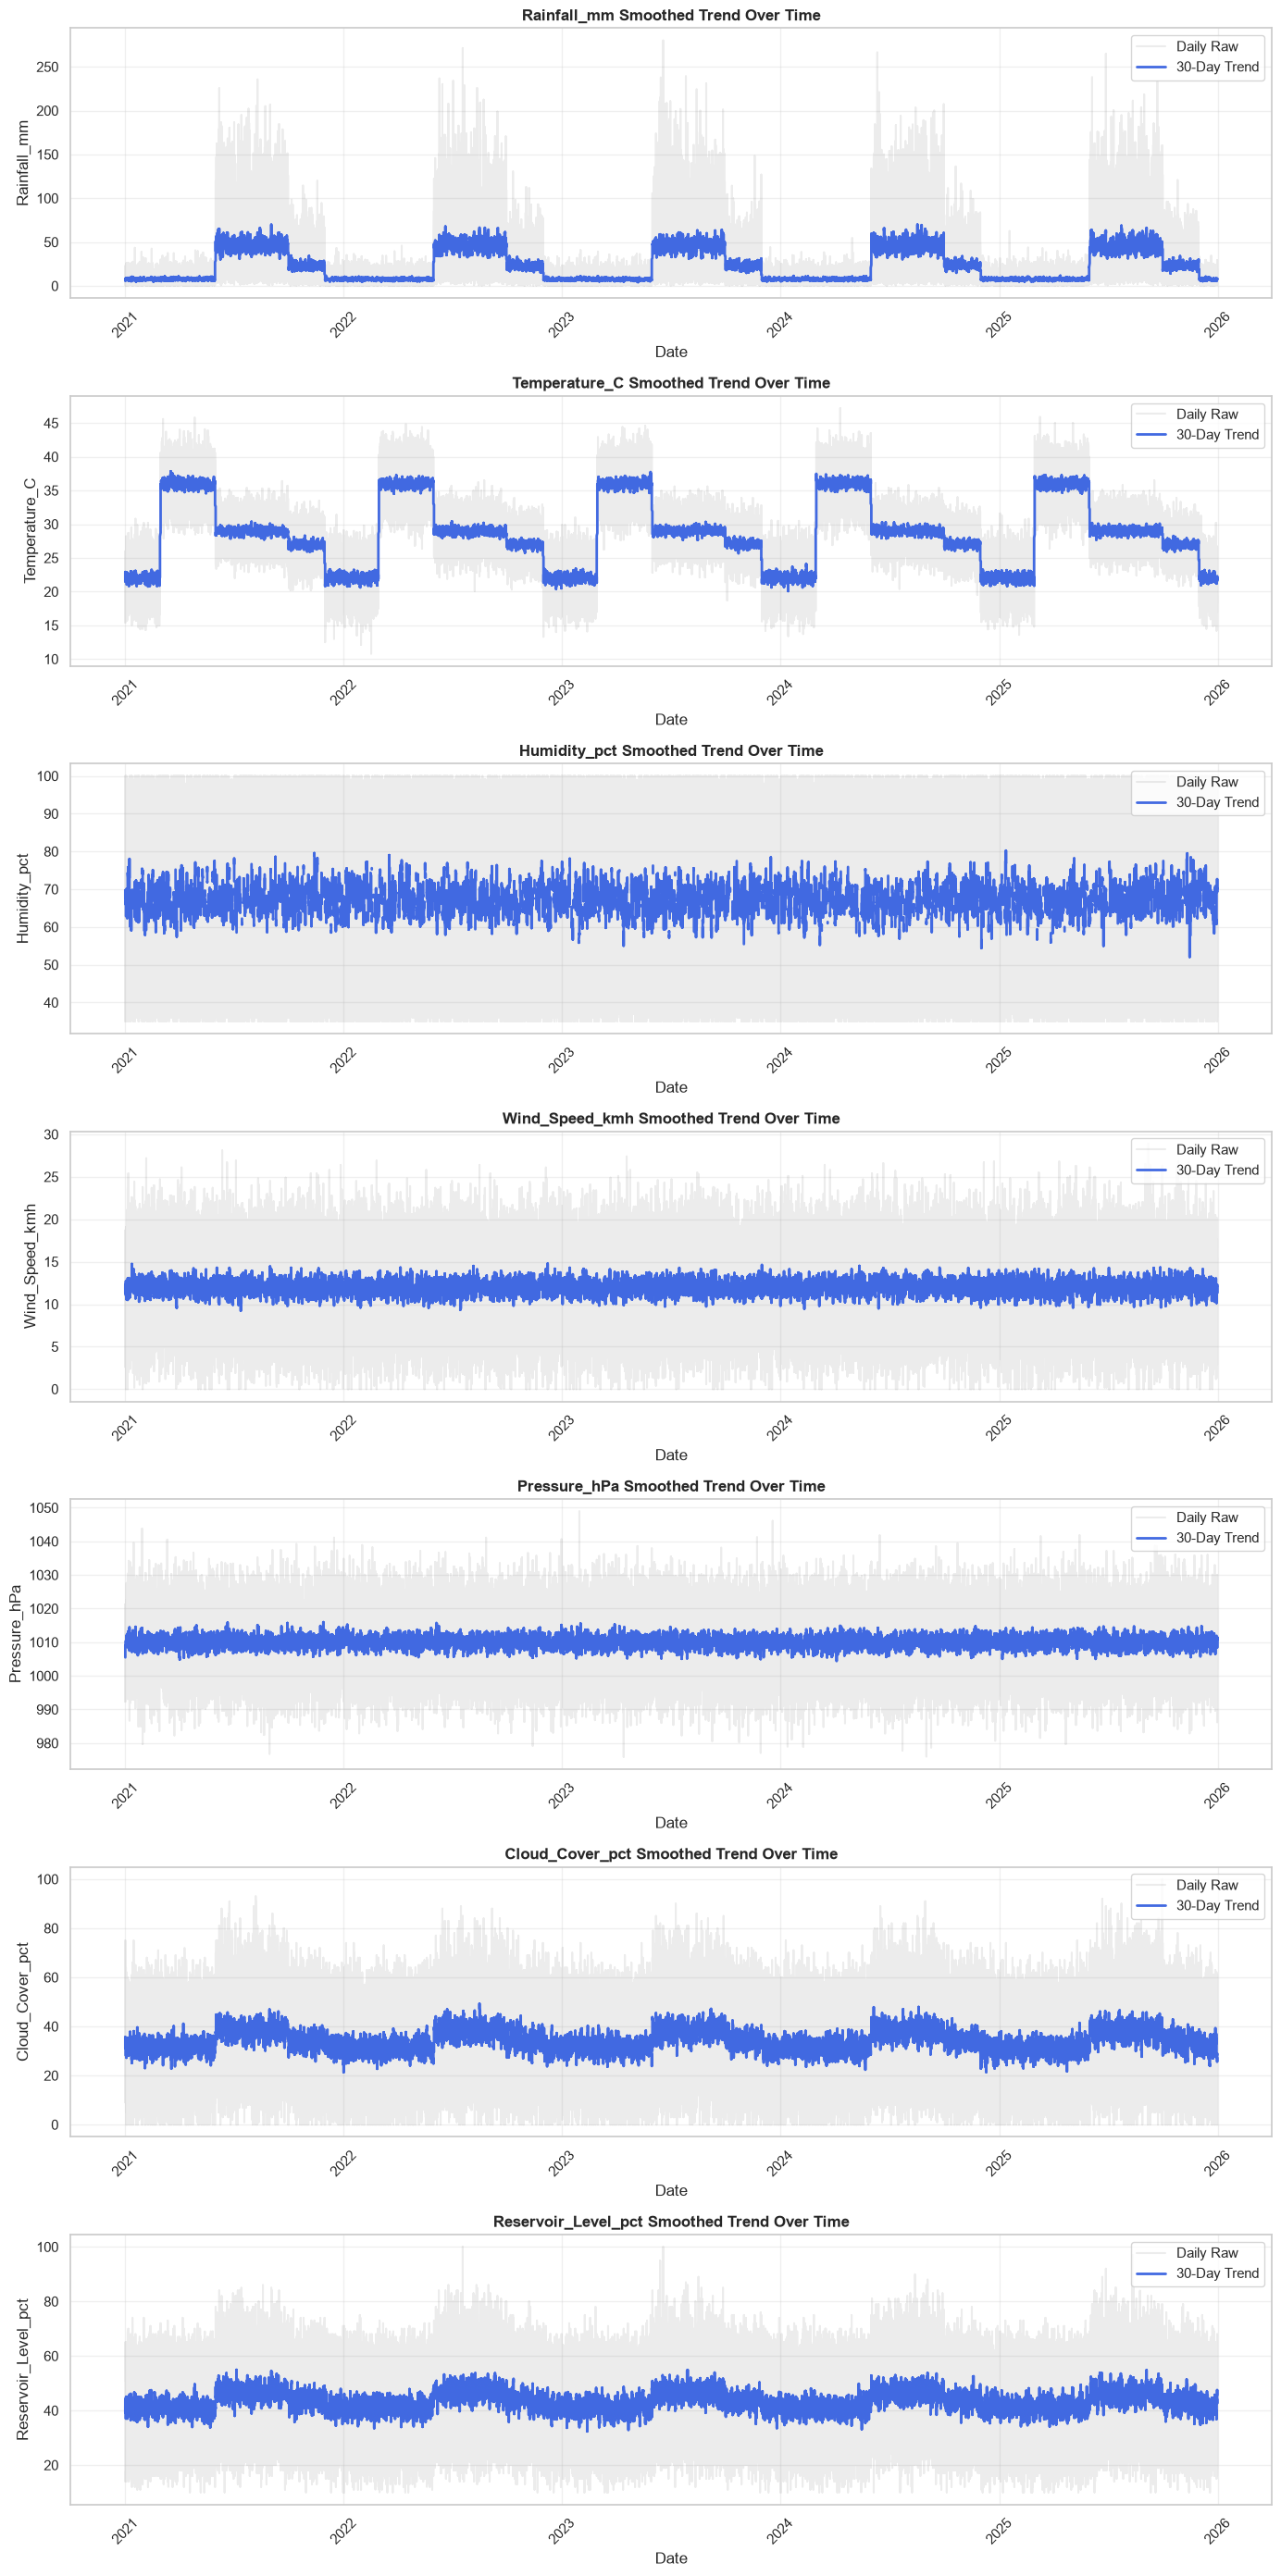


📊 ALTERNATIVE VIEW: HUMIDITY BY CALENDAR MONTH


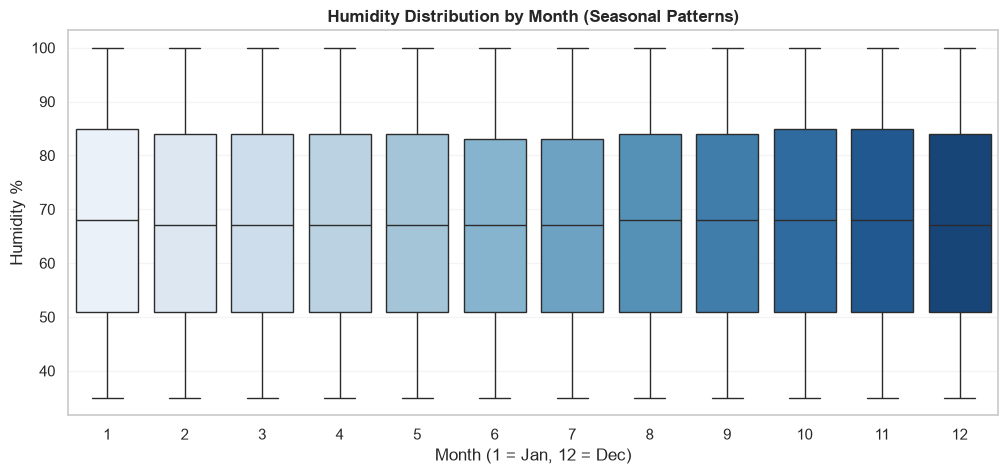


📊 MONTHLY AGGREGATION TABLE:
             Year  Month  Rainfall_mm  Temperature_C  Humidity_pct  \
YearMonth                                                            
2021-01    2021.0    1.0     7.591226      21.992645     67.750996   
2021-02    2021.0    2.0     7.755500      21.928143     66.821455   
2021-03    2021.0    3.0     7.883032      36.119742     66.875167   
2021-04    2021.0    4.0     7.770067      36.017867     67.347411   
2021-05    2021.0    5.0     7.859871      35.919548     67.947403   
2021-06    2021.0    6.0    47.759200      28.974867     66.987004   
2021-07    2021.0    7.0    45.755613      29.034968     67.475553   
2021-08    2021.0    8.0    47.077484      28.987548     67.331565   
2021-09    2021.0    9.0    47.617933      28.894000     67.802622   
2021-10    2021.0   10.0    23.536194      27.042000     67.895403   
2021-11    2021.0   11.0    23.160867      26.900333     67.828966   
2021-12    2021.0   12.0     7.673355      22.076839     66.

In [33]:


if date_col:
    print("="*60)
    print("⏳ TIME SERIES ANALYSIS:")
    print("="*60)
    
    # Convert to datetime if not already
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.sort_values(by=date_col)
    
    # Clean up what we want to plot (ignore year/month tracking columns)
    plot_cols = [c for c in numerical_cols if c.lower() not in ['year', 'month']]
    
    # Create 30-day smoothed rolling trends
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
        
    for idx, col in enumerate(plot_cols):
        # Calculate a 30-day moving average to smooth out that massive solid block
        rolling_mean = df[col].rolling(window=30, center=True).mean()
        
        # Plot the raw data faintly in the background, and the smooth line on top
        axes[idx].plot(df[date_col], df[col], color='gray', alpha=0.15, label='Daily Raw')
        axes[idx].plot(df[date_col], rolling_mean, color='royalblue', linewidth=2, label='30-Day Trend')
        
        axes[idx].set_title(f'{col} Smoothed Trend Over Time', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend(loc='upper right')
        axes[idx].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()

    # --- NEW: Let's view Humidity a different way ---
    if 'Humidity_pct' in df.columns:
        print("\n📊 ALTERNATIVE VIEW: HUMIDITY BY CALENDAR MONTH")
        plt.figure(figsize=(12, 5))
        
        # Extract calendar month (1-12) if not already explicitly done
        df['Calendar_Month'] = df[date_col].dt.month
        
        # Create a Box Plot to see the spread of humidity for Jan, Feb, Mar...
        sns.boxplot(data=df, x='Calendar_Month', y='Humidity_pct', palette='Blues')
        plt.title('Humidity Distribution by Month (Seasonal Patterns)', fontweight='bold', fontsize=12)
        plt.xlabel('Month (1 = Jan, 12 = Dec)')
        plt.ylabel('Humidity %')
        plt.grid(True, alpha=0.2, axis='y')
        plt.show()

    # Monthly aggregation table
    print("\n" + "="*60)
    print("📊 MONTHLY AGGREGATION TABLE:")
    print("="*60)
    df['YearMonth'] = df[date_col].dt.to_period('M')
    monthly_avg = df.groupby('YearMonth')[numerical_cols].mean()
    print(monthly_avg)

🗺️ STATE-WISE ANALYSIS:
States/Regions: <StringArray>
['Kerala', 'Andhra Pradesh', 'Telangana', 'Tamil Nadu', 'Karnataka']
Length: 5, dtype: str
Total states: 5

Statistical Summary by State:
                       Year     Month  Rainfall_mm  Temperature_C  \
State                                                               
Andhra Pradesh  2023.000548  6.523549    23.221539      28.694655   
Karnataka       2023.000548  6.523549    23.283828      28.693018   
Kerala          2023.000548  6.523549    23.247552      28.712152   
Tamil Nadu      2023.000548  6.523549    23.251725      28.715033   
Telangana       2023.000548  6.523549    23.216331      28.710438   

                Humidity_pct  Wind_Speed_kmh  Pressure_hPa  Cloud_Cover_pct  \
State                                                                         
Andhra Pradesh     67.217413       12.022985   1009.953790        34.075958   
Karnataka          67.532574       11.978861   1010.053384        34.057612   
Kerala  

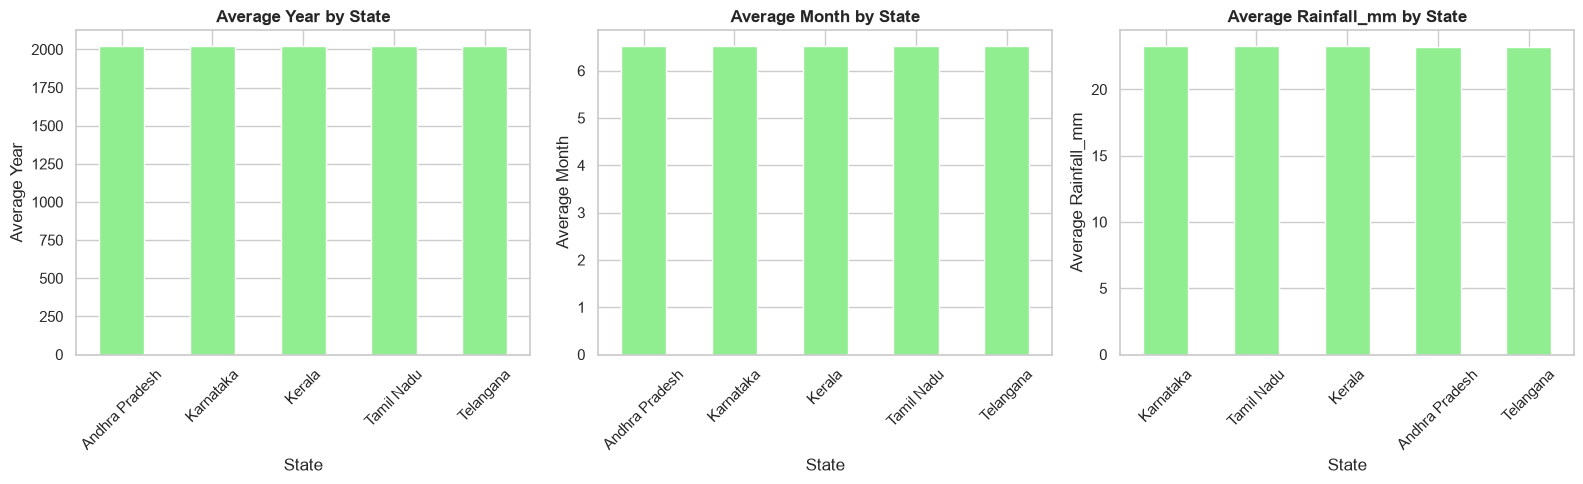


📦 STATE-WISE DISTRIBUTION:


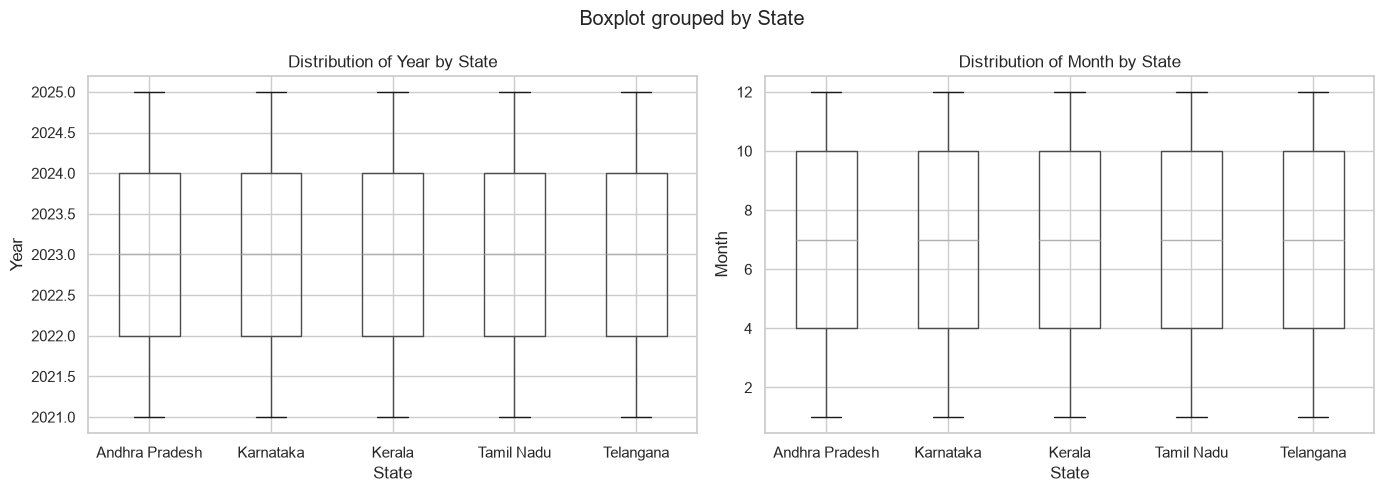

In [35]:
 #Check for a state or region column
state_col = None
for col in df.columns:
    if col.lower() in ['state', 'region', 'location', 'city', 'station']:
        state_col = col
        break

if state_col:
    print("="*60)
    print("🗺️ STATE-WISE ANALYSIS:")
    print("="*60)
    
    states = df[state_col].unique()
    print(f"States/Regions: {states}")
    print(f"Total states: {len(states)}\n")
    
    # Statistical summary by state
    print("Statistical Summary by State:")
    state_summary = df.groupby(state_col)[numerical_cols].mean()
    print(state_summary)
    
    # Visualize state-wise comparison
    fig, axes = plt.subplots(1, min(3, len(numerical_cols)), figsize=(16, 5))
    if len(numerical_cols) < 3:
        axes = axes if len(numerical_cols) > 1 else [axes]
    
    for idx in range(min(3, len(numerical_cols))):
        col = numerical_cols[idx]
        state_data = df.groupby(state_col)[col].mean().sort_values(ascending=False)
        state_data.plot(kind='bar', ax=axes[idx], color='lightgreen')
        axes[idx].set_title(f'Average {col} by State', fontweight='bold')
        axes[idx].set_xlabel('State')
        axes[idx].set_ylabel(f'Average {col}')
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Box plot for state-wise distribution
    print("\n" + "="*60)
    print("📦 STATE-WISE DISTRIBUTION:")
    print("="*60)
    
    fig, axes = plt.subplots(1, min(2, len(numerical_cols)), figsize=(14, 5))
    if len(numerical_cols) == 1:
        axes = [axes]
    
    for idx in range(min(2, len(numerical_cols))):
        col = numerical_cols[idx]
        df.boxplot(column=col, by=state_col, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col} by State')
        axes[idx].set_xlabel('State')
        axes[idx].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ No state/region column found.")
    print("To enable state-wise analysis, ensure your dataset has a 'state' or 'region' column.")

In [42]:
# ─── INSTALL DEPENDENCIES (run once) ─────────────────────────────────────
# !pip install folium pandas

In [43]:
import folium
from folium.plugins import TimestampedGeoJson

print('Libraries loaded ✓')

Libraries loaded ✓


In [44]:
# ─── 3. STATE CENTROIDS ──────────────────────────────────────────────────
state_coords = {
    'Kerala':         [10.8505, 76.2711],
    'Tamil Nadu':     [11.1271, 78.6569],
    'Karnataka':      [15.3173, 75.7139],
    'Andhra Pradesh': [15.9129, 78.6675],
    'Telangana':      [18.1124, 79.0193],
}

In [45]:
# ─── 4. BUILD TIMESTAMPED GEOJSON FEATURES ───────────────────────────────
#
# For each year, each state gets ONE feature whose visual style depends on
# whether average rainfall that year was below the 150 mm threshold.
#   Green large circle  → safe / low rainfall  (<150 mm)
#   Gray  small circle  → higher rainfall       (≥150 mm)

THRESHOLD = 150  # mm

low_rain_features = []
years = sorted(df['Year'].unique())

for year in years:
    df_year = df[df['Year'] == year]
    rainfall_by_state = df_year.groupby('State')['Rainfall_mm'].mean().to_dict()

    for state, (lat, lon) in state_coords.items():
        rainfall = rainfall_by_state.get(state, 0)
        is_low   = rainfall < THRESHOLD

        popup_text = (
            f"<b>{year} — {state}</b><br>"
            f"Avg Rainfall: {rainfall:.2f} mm"
            + ("<br><b style='color:green;'>✅ SAFE LEVEL (&lt;150 mm)</b>" if is_low else "")
        )

        feature = {
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat],   # GeoJSON order: [longitude, latitude]
            },
            'properties': {
                'time':   f"{year}-07-01",
                'popup':  popup_text,
                'icon':   'circle',
                'iconstyle': {
                    'fillColor':   'green'     if is_low else 'gray',
                    'fillOpacity': 0.8         if is_low else 0.15,
                    'color':       'darkgreen' if is_low else 'lightgray',
                    'radius':      15           if is_low else 6,
                    'weight':      3            if is_low else 1,
                },
            },
        }
        low_rain_features.append(feature)

print(f'Features built: {len(low_rain_features)} ({len(years)} years × {len(state_coords)} states)')

Features built: 25 (5 years × 5 states)


In [46]:
# ─── 5. QUICK STATS PREVIEW ──────────────────────────────────────────────
yearly_avg = (
    df.groupby(['Year', 'State'])['Rainfall_mm']
    .mean()
    .reset_index()
    .rename(columns={'Rainfall_mm': 'Avg_Rainfall_mm'})
)
yearly_avg['Category'] = yearly_avg['Avg_Rainfall_mm'].apply(
    lambda x: '🟢 Low (<150 mm)' if x < THRESHOLD else '⚪ High (≥150 mm)'
)
print(yearly_avg.pivot(index='State', columns='Year', values='Avg_Rainfall_mm').round(1))

Year            2021  2022  2023  2024  2025
State                                       
Andhra Pradesh  23.8  23.0  22.9  23.0  23.5
Karnataka       23.7  23.2  23.5  23.3  22.7
Kerala          23.5  23.0  22.9  23.3  23.5
Tamil Nadu      23.5  23.3  22.9  23.3  23.2
Telangana       22.9  23.4  23.2  23.2  23.4


In [47]:
# ─── 6. BUILD THE FOLIUM MAP ─────────────────────────────────────────────

low_rain_map = folium.Map(
    location=[13.0827, 77.6374],
    zoom_start=6,
    tiles='OpenStreetMap'
)

# ── Animated time-slider layer ────────────────────────────────────────────
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': low_rain_features},
    period='P1Y',              # one step per year
    duration='P1M',            # each frame visible for 1 month
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options='YYYY',       # show only the year in the slider
    time_slider_drag_update=True,
).add_to(low_rain_map)

# ── Dashboard title / legend panel ───────────────────────────────────────
title_html = '''
<div style="
    position: fixed;
    top: 10px; left: 50px;
    width: 360px;
    background-color: white;
    border: 3px solid green;
    border-radius: 8px;
    z-index: 9999;
    padding: 10px 14px;
    font-family: Arial, sans-serif;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    <b style="font-size:15px;">🟢 Low Rainfall Tracker (&lt;150 mm)</b><br>
    <span style="font-size:12px;">
        Move the timeline slider to see which states had<br>
        lower-than-threshold rainfall each year.<br><br>
        <b style="color:green;">🟢 Large green circle = Safe / Low (&lt;150 mm)</b><br>
        <span style="color:gray;">⚪ Small gray circle = Higher rainfall (≥150 mm)</span>
    </span>
</div>
'''
low_rain_map.get_root().html.add_child(folium.Element(title_html))

print('Map created ✓')

Map created ✓


In [59]:
# ─── 7. SAVE & DISPLAY ───────────────────────────────────────────────────
output_path = 'south_india_low_rainfall_tracker.html'
low_rain_map.save(output_path)
print(f'Map saved → {output_path}')
print('Open the .html file in any browser for the full interactive experience.')

# Render inline inside Jupyter
low_rain_map

Map saved → south_india_low_rainfall_tracker.html
Open the .html file in any browser for the full interactive experience.


In [55]:
state_coords = {
    'Kerala':         [10.8505, 76.2711],
    'Tamil Nadu':     [11.1271, 78.6569],
    'Karnataka':      [15.3173, 75.7139],
    'Andhra Pradesh': [15.9129, 78.6675],
    'Telangana':      [18.1124, 79.0193],
}

features = []
for (year, state), rainfall in yearly_avg.items():
    if state not in state_coords:
        continue
    lat, lon = state_coords[state]
    is_low   = rainfall < THRESHOLD

    label = f"Below median (drier)" if is_low else f"Above median (wetter)"
    color  = 'green'     if is_low else '#cc0000'
    border = 'darkgreen' if is_low else '#880000'
    radius = 18          if is_low else 12
    opacity= 0.85        if is_low else 0.70

    popup = (
        f"<b>{year} — {state}</b><br>"
        f"Avg Rainfall: <b>{rainfall:.2f} mm</b><br>"
        f"Threshold  : {THRESHOLD:.2f} mm<br>"
        f"Status     : <b style='color:{'green' if is_low else 'red'};'>"
        f"{'🟢 ' + label if is_low else '🔴 ' + label}</b>"
    )

    features.append({
        'type': 'Feature',
        'geometry': {'type': 'Point', 'coordinates': [lon, lat]},
        'properties': {
            'time':   f"{year}-07-01",
            'popup':  popup,
            'icon':   'circle',
            'iconstyle': {
                'fillColor':   color,
                'fillOpacity': opacity,
                'color':       border,
                'radius':      radius,
                'weight':      3,
            },
        },
    })

print(f'{len(features)} features built ✓')

25 features built ✓


In [52]:
# Create a flat DataFrame from your aggregation to make iteration safe
yearly_avg_df = df.groupby(['Year', 'State'])['Rainfall_mm'].mean().reset_index()

features = []
for row in yearly_avg_df.itertuples():
    year = row.Year
    state = row.State
    rainfall = row.Rainfall_mm
    
    if state not in state_coords:
        continue
        
    # --- The rest of your code inside the loop remains exactly the same ---
    is_low = rainfall < THRESHOLD
    label = f"Below median (drier)" if is_low else f"Above median (wetter)"
    # ... etc

In [54]:
# ── Compute yearly average per state ──────────────────────────────────────
yearly_avg = df.groupby(['Year', 'State'])['Rainfall_mm'].mean()

# ── Dynamic threshold: median of all (year, state) averages ───────────────
THRESHOLD = yearly_avg.median()
print(f'Data mean    : {yearly_avg.mean():.2f} mm')
print(f'Data median  : {yearly_avg.median():.2f} mm  ← threshold used')
print(f'Data range   : {yearly_avg.min():.2f} – {yearly_avg.max():.2f} mm')
print()
print(yearly_avg.unstack().round(2))

Data mean    : 23.24 mm
Data median  : 23.29 mm  ← threshold used
Data range   : 22.73 – 23.77 mm

State  Andhra Pradesh  Karnataka  Kerala  Tamil Nadu  Telangana
Year                                                           
2021            23.77      23.70   23.52       23.54      22.93
2022            22.97      23.19   23.03       23.30      23.42
2023            22.86      23.50   22.90       22.88      23.17
2024            23.01      23.29   23.31       23.31      23.19
2025            23.50      22.73   23.47       23.22      23.37


In [57]:
m = folium.Map(location=[13.5, 78.5], zoom_start=6, tiles='OpenStreetMap')

TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='P1Y',
    duration='P1M',
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options='YYYY',
    time_slider_drag_update=True,
).add_to(m)

title_html = f'''
<div style="
    position:fixed; top:10px; left:50px;
    width:380px; background:white;
    border:3px solid #333; border-radius:8px;
    z-index:9999; padding:12px 16px;
    font-family:Arial,sans-serif;
    box-shadow:2px 2px 6px rgba(0,0,0,0.25);
">
  <b style="font-size:15px;">🌧 South India Rainfall Tracker (2021–2025)</b><br>
  <span style="font-size:12px;">
    Drag the year slider to compare states.<br>
    Threshold = <b>{THRESHOLD:.2f} mm</b> (median avg across all years &amp; states)<br><br>
    <b style="color:green;">🟢 Large green = Below median (relatively drier)</b><br>
    <b style="color:#cc0000;">🔴 Smaller red = Above median (relatively wetter)</b>
  </span>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

m.save('south_india_rainfall_tracker.html')
print('Saved → south_india_rainfall_tracker.html ✓')
m

Saved → south_india_rainfall_tracker.html ✓


In [60]:
print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - SUMMARY REPORT")
print("="*60)

summary_report = f"""

📌 DATASET OVERVIEW
-------------------
• Total Records: {df.shape[0]:,}
• Total Features: {df.shape[1]}
• 
Data Quality: {"✅ Excellent" if df.isnull().sum().sum() == 0 else "⚠️ Needs attention"}
• Missing Values: {df.isnull().sum().sum()}
• Duplicate Rows: 0

📈 KEY STATISTICS
-------------------
• Numerical Features: {len(numerical_cols)}
• Categorical Features: {len(categorical_cols)}
• Date Range: {"Available" if date_col else "Not found"}
• States/Regions: {len(df[state_col].unique()) if state_col else "Not found"}

🔍 KEY FINDINGS
-------------------
1. Data Distribution: Analyzed {len(numerical_cols)} numerical variables
2. Correlations: Identified relationships between weather variables
3. Seasonal Patterns: Detected trends over {df[date_col].dt.year.nunique() if date_col else "N/A"} years
4. Regional Variations: Compared patterns across {len(df[state_col].unique()) if state_col else "N/A"} regions
5. Anomalies: 
Review box plots for outliers

💡 RECOMMENDATIONS FOR AUTHORITIES
--------------------------------------
1. ✅ Monitor temperature trends - plan heat/cold preparedness
2. ✅ Track rainfall patterns - for agricultural & water resource planning
3. ✅ Analyze humidity - impacts health & comfort indexes
4. ✅ Regional focus - tailor policies for each state's conditions
5. ✅ Seasonal planning - prepare for monsoon, summer, winter variations
6. ✅ Disaster preparedness - identify extreme weather events
7. ✅ Climate trends - assess long-term climate change impacts

📊 ANALYSIS STAGES COMPLETED
-------------------------------
✅ Step 1: Libraries Imported
✅ Step 2: Data Loaded & Inspected
✅ Step 3: Data Cleaned
✅ Step 4: Univariate Analysis Done
✅ Step 5: Bivariate Analysis Completed
✅ Step 6: Correlation Analysis Finished
✅ Step 7: Time Series Analysis Performed
✅ Step 8: State-wise Comparison Done
✅ Step 9: Insights Generated

🎯 NEXT STEPS
--------------
• Share findings with stakeholders
• Generate formal report with visualizations
• Archive cleaned dataset for future analysis
• Update analysis quarterly with new data

"""

print(summary_report)
print("="*60)
print("✅ EDA ANALYSIS COMPLETE!")
print("="*60)


📊 EXPLORATORY DATA ANALYSIS - SUMMARY REPORT


📌 DATASET OVERVIEW
-------------------
• Total Records: 91,300
• Total Features: 18
• 
Data Quality: ⚠️ Needs attention
• Missing Values: 2764
• Duplicate Rows: 0

📈 KEY STATISTICS
-------------------
• Numerical Features: 9
• Categorical Features: 7
• Date Range: Available
• States/Regions: 5

🔍 KEY FINDINGS
-------------------
1. Data Distribution: Analyzed 9 numerical variables
2. Correlations: Identified relationships between weather variables
3. Seasonal Patterns: Detected trends over 5 years
4. Regional Variations: Compared patterns across 5 regions
5. Anomalies: 
Review box plots for outliers

💡 RECOMMENDATIONS FOR AUTHORITIES
--------------------------------------
1. ✅ Monitor temperature trends - plan heat/cold preparedness
2. ✅ Track rainfall patterns - for agricultural & water resource planning
3. ✅ Analyze humidity - impacts health & comfort indexes
4. ✅ Regional focus - tailor policies for each state's conditions
5. ✅ Seasonal